Notebook for building analysis of resulting synapse distribution

In [1]:
import os
import sys
sys.path.append("../")
sys.path.append("../Modules/")
import pandas as pd
import h5py

from Modules import analysis
from Modules import view_synapses

## Pick Simulation

In [2]:
sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-01-00-13-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0000_DepthDistalInh0.0000_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1100_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_1.2982_Np5000"

sim_dir = "/home/drfrbc/Neural-Modeling/scripts/2025-04-02-11-37-Running_5sec_STA_noRhyth/sta_Complex_DepthPeriInh0.0150_DepthDistalInh0.0150_InhTuftDensity0.3300_0.4400_0.3850_0.0572_0.2200_0.1650_ExcTuftDensity0.4860_0.3240_0.1080_0.5400_0.6491_Np5000"

In [3]:
save_folder = os.path.join(sim_dir, 'synapse_distribution')

if not os.path.exists(save_folder):
    os.mkdir(save_folder)

## Loading Data

Read files

In [4]:
# read synapses from simulation
syn_data = view_synapses.read_synapse_distribution_file(sim_dir)

# read segment data from simulation
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))

# read transfer impedances
imp_df = view_synapses.read_transfer_impedance_file(sim_dir, loc='soma')
seg_data['soma_trans_imp'] = imp_df.beta_active

# add segment information of synapse location
syn_data = view_synapses.add_seg_info_to_syn_data(syn_data, seg_data)

Choose transfer impedance for analysis

In [5]:
# choose transfer impedance
seg_data['soma_trans_imp'] = imp_df.beta_active

Check that the seg indices correspond

In [6]:
# checks
if len(seg_data) != len(imp_df):
    IndexError(f"{len(seg_data)} != {max(syn_data.seg_id)}. The imp_df does not correspond to seg_data")
if len(seg_data) != max(syn_data.seg_id):
    print(f"{len(seg_data)} != {max(syn_data.seg_id)} need to check that syn_data.seg_id actually corresponds to seg_data row index.")

2630 != 2507 need to check that syn_data.seg_id actually corresponds to seg_data row index.


Previews

In [7]:
seg_data

,Unnamed: 0,section,idx_in_section_type,seg_half_seg_RA,L,seg,pseg,Section_L,Section_diam,Distance,...,pc_1,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,soma_trans_imp
0,0,soma,0,0.081276,23.169408,L5PCtemplate[0].soma[0](0.5),None,23.169408,13.471518,0.000000,...,18.343678,-50.250000,57.287731,19.065830,-50.250000,6.735759,23.124348,1.444304,0.000000,1.000000
1,1,dend,0,2.647135,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,20.787594,-50.027254,61.001504,21.408927,-49.444755,0.539452,4.591504,1.178928,0.805245,0.929486
2,2,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,21.939324,-50.557475,64.964606,21.737526,-51.687077,0.585000,3.963102,0.328599,-2.242322,0.851091
3,3,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,21.040891,-51.991813,68.301396,20.356904,-50.119401,0.585000,3.336790,-1.380622,1.567676,0.781747
4,4,dend,0,2.250969,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,19.672918,-48.246989,70.726764,18.807201,-46.252588,0.585000,2.425368,-1.549704,3.866813,0.720767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2625,2625,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.653846),L5PCtemplate[0].axon[0](0.576923),60.000004,1.000000,39.230772,...,57.574449,-50.250000,45.725559,59.882142,-50.250000,0.500000,0.000000,4.615385,0.000000,0.436135
2626,2626,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.730769),L5PCtemplate[0].axon[0](0.653846),60.000004,1.000000,43.846157,...,62.189834,-50.250000,45.725559,64.497527,-50.250000,0.500000,0.000000,4.615385,0.000000,0.406617
2627,2627,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.807692),L5PCtemplate[0].axon[0](0.730769),60.000004,1.000000,48.461542,...,66.805219,-50.250000,45.725559,69.112912,-50.250000,0.500000,0.000000,4.615385,0.000000,0.380675
2628,2628,axon,0,2.938245,4.615385,L5PCtemplate[0].axon[0](0.884615),L5PCtemplate[0].axon[0](0.807692),60.000004,1.000000,53.076926,...,71.420604,-50.250000,45.725559,73.728296,-50.250000,0.500000,0.000000,4.615385,0.000000,0.357720


In [8]:
syn_data

,mean_firing_rate,pc_name,seg_id,synapse_type,weight,Distance,section,soma_trans_imp,seg_L
0,12.4,b'fg_4_cell31',981,inh_perisomatic,4.405925,79.153520,dend,0.189519,4.166857
1,15.0,b'fg_8_cell43',383,inh_perisomatic,4.586803,75.802122,dend,0.264939,4.714555
2,15.8,b'fg_8_cell30',1028,inh_perisomatic,4.460333,65.724328,dend,0.047363,4.757057
3,11.8,b'fg_4_cell22',458,inh_perisomatic,4.571528,142.351553,dend,0.027283,4.985891
4,14.8,b'fg_8_cell12',2465,inh_perisomatic,4.544934,254.028500,apic,0.092785,4.771715
...,...,...,...,...,...,...,...,...,...
9644,2.2,b'fg_38_cell71',72,exc_distal_basal,1.198728,98.838927,dend,0.119216,4.952402
9645,5.0,b'fg_49_cell0',197,exc_distal_basal,1.180987,75.337118,dend,0.216035,4.886585
9646,0.2,b'fg_36_cell19',256,exc_distal_basal,1.124377,61.851429,dend,0.303363,4.500404
9647,9.8,b'fg_33_cell94',85,exc_distal_basal,1.163203,163.220151,dend,0.045028,4.952402


## Plotting on Morphology

In [9]:
import pandas as pd

# Assume df is your existing dataframe
# Example: Create a column that classifies synapses as 'exc' or 'inh'
syn_data['synapse_class'] = syn_data['synapse_type'].apply(lambda x: 'exc' if x.startswith('exc') else ('inh' if x.startswith('inh') else None))

# Filter the dataframe into excitatory and inhibitory synapses
df_exc = syn_data[syn_data['synapse_class'] == 'exc']
df_inh = syn_data[syn_data['synapse_class'] == 'inh']

# Group by 'seg_id' and aggregate all other columns into lists
df_exc_grouped = df_exc.groupby('seg_id').agg(lambda x: list(x)).reset_index()
df_inh_grouped = df_inh.groupby('seg_id').agg(lambda x: list(x)).reset_index()

# Display the resulting dataframes
print("Excitatory synapses grouped by segment:")
print(df_exc_grouped)
print("\nInhibitory synapses grouped by segment:")
print(df_inh_grouped)


Excitatory synapses grouped by segment:
      seg_id          mean_firing_rate  \
0         12              [11.4, 11.4]   
1         13              [11.4, 11.4]   
2         14  [17.4, 17.4, 17.4, 17.4]   
3         15           [8.4, 8.4, 8.4]   
4         16      [6.4, 6.6, 6.8, 6.6]   
...      ...                       ...   
2049    2501                     [5.2]   
2050    2503      [0.2, 0.2, 0.2, 8.6]   
2051    2504           [4.4, 4.4, 4.4]   
2052    2505                     [4.2]   
2053    2506                [2.6, 2.6]   

                                                pc_name  \
0                      [b'fg_5_cell42', b'fg_5_cell42']   
1                      [b'fg_5_cell42', b'fg_5_cell42']   
2     [b'fg_38_cell10', b'fg_38_cell10', b'fg_38_cel...   
3     [b'fg_38_cell54', b'fg_38_cell54', b'fg_38_cel...   
4     [b'fg_38_cell99', b'fg_38_cell41', b'fg_38_cel...   
...                                                 ...   
2049                                  [b'f

In [10]:
import numpy as np
for df in [df_exc_grouped, df_inh_grouped]:

    df['seg_L'] = df['seg_L'].apply(np.mean)
    df['pc_name'] = np.array(df['pc_name'].apply(np.array))
    df['num_syns'] = df['pc_name'].apply(len)
    df['num_cells'] = df['pc_name'].apply(np.unique).apply(len) # number of cells per segment
    df['weight_mean'] = df['weight'].apply(np.mean) # mean weight
    df['weight_std'] = df['weight'].apply(np.std) # mean weight
    df['weight_sum'] = df['weight'].apply(np.sum) # mean weight

    # do same for fr
    df['fr_mean'] = df['mean_firing_rate'].apply(np.mean) # mean weight
    df['fr_std'] = df['mean_firing_rate'].apply(np.std) # mean weight
    df['fr_sum'] = df['mean_firing_rate'].apply(np.sum) # mean weight

    # Multiply weight and firing rate and sum
    df['weightXfr'] = df.apply(lambda row: [a * b for a, b in zip(row['weight'], row['mean_firing_rate'])], axis=1)
    df['weightXfr_sum'] = df['weightXfr'].apply(np.sum) # mean weight

    df['syn_density'] = df.apply(lambda row: [row['num_syns'] / row['seg_L']], axis=1)

In [11]:
df_inh_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,1,"[15.0, 15.0]","[b'fg_8_cell43', b'fg_8_cell43']","[inh_perisomatic, inh_perisomatic]","[4.4723234672952925, 4.711165017873848]","[2.420087823010826, 2.420087823010826]","[dend, dend]","[0.9294862015894018, 0.9294862015894018]",4.840176,"[inh, inh]",...,1,4.591744,0.119421,9.183488,15.0,0.0,30.0,"[67.08485200942938, 70.66747526810771]",137.752327,[0.413208144965542]
1,2,[15.0],[b'fg_8_cell43'],[inh_perisomatic],[4.7660495256231625],[7.260263469032476],[dend],[0.8510913839976284],4.840176,[inh],...,1,4.766050,0.000000,4.766050,15.0,0.0,15.0,[71.49074288434744],71.490743,[0.206604072482771]
2,5,[15.0],[b'fg_8_cell43'],[inh_perisomatic],[4.618887724326055],[21.78079040709743],[dend],[0.6671984241317321],4.840176,[inh],...,1,4.618888,0.000000,4.618888,15.0,0.0,15.0,[69.28331586489082],69.283316,[0.206604072482771]
3,6,"[23.8, 23.8]","[b'fg_8_cell20', b'fg_8_cell20']","[inh_perisomatic, inh_perisomatic]","[4.542412436985634, 4.545588070309371]","[26.09865275948857, 26.09865275948857]","[dend, dend]","[0.6114098184201815, 0.6114098184201815]",3.795549,"[inh, inh]",...,1,4.544000,0.001588,9.088001,23.8,0.0,47.6,"[108.1094160002581, 108.18499607336304]",216.294412,[0.5269329862523419]
4,12,"[16.8, 16.8]","[b'fg_8_cell3', b'fg_8_cell3']","[inh_distal_basal, inh_distal_basal]","[2.010386855093, 1.9267822132679733]","[51.61299802400147, 51.61299802400147]","[dend, dend]","[0.2819834556992703, 0.2819834556992703]",4.891969,"[inh, inh]",...,1,1.968585,0.041802,3.937169,16.8,0.0,33.6,"[33.7744991655624, 32.369941182901954]",66.144440,[0.4088332994020659]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914,2503,"[25.4, 25.4]","[b'fg_6_cell25', b'fg_6_cell25']","[inh_oblique, inh_oblique]","[1.742611425037666, 1.992801825627776]","[226.622336407936, 226.622336407936]","[apic, apic]","[0.1513696227505099, 0.1513696227505099]",4.981013,"[inh, inh]",...,1,1.867707,0.125095,3.735413,25.4,0.0,50.8,"[44.262330195956714, 50.617166370945505]",94.879497,[0.40152477614234927]
1915,2504,"[25.4, 25.4]","[b'fg_6_cell25', b'fg_6_cell25']","[inh_oblique, inh_oblique]","[1.8137803211142787, 1.8577932012501377]","[231.6033490847004, 231.6033490847004]","[apic, apic]","[0.1374426165981383, 0.1374426165981383]",4.981013,"[inh, inh]",...,1,1.835787,0.022006,3.671574,25.4,0.0,50.8,"[46.070020156302675, 47.1879473117535]",93.257967,[0.40152477614234927]
1916,2505,[14.4],[b'fg_4_cell14'],[inh_oblique],[1.7945047184702194],[236.58436176146463],[apic],[0.1258277634196074],4.981013,[inh],...,1,1.794505,0.000000,1.794505,14.4,0.0,14.4,[25.84086794597116],25.840868,[0.20076238807117464]
1917,2506,[14.4],[b'fg_4_cell14'],[inh_oblique],[1.7467442762213532],[241.565374438229],[apic],[0.1159951420116688],4.981013,[inh],...,1,1.746744,0.000000,1.746744,14.4,0.0,14.4,[25.153117577587487],25.153118,[0.20076238807117464]


In [12]:
df_exc_grouped

,seg_id,mean_firing_rate,pc_name,synapse_type,weight,Distance,section,soma_trans_imp,seg_L,synapse_class,...,num_cells,weight_mean,weight_std,weight_sum,fr_mean,fr_std,fr_sum,weightXfr,weightXfr_sum,syn_density
0,12,"[11.4, 11.4]","[b'fg_5_cell42', b'fg_5_cell42']","[exc_distal_basal, exc_distal_basal]","[1.1606995239707125, 0.917113083562761]","[51.61299802400147, 51.61299802400147]","[dend, dend]","[0.2819834556992703, 0.2819834556992703]",4.891969,"[exc, exc]",...,1,1.038906,0.121793,2.077813,11.4,0.000000,22.8,"[13.231974573266124, 10.455089152615475]",23.687064,[0.4088332994020659]
1,13,"[11.4, 11.4]","[b'fg_5_cell42', b'fg_5_cell42']","[exc_distal_basal, exc_distal_basal]","[1.20526045171225, 1.3859048261835645]","[56.50496744754177, 56.50496744754177]","[dend, dend]","[0.2445401036871202, 0.2445401036871202]",4.891969,"[exc, exc]",...,1,1.295583,0.090322,2.591165,11.4,0.000000,22.8,"[13.73996914951965, 15.799315018492635]",29.539284,[0.4088332994020659]
2,14,"[17.4, 17.4, 17.4, 17.4]","[b'fg_38_cell10', b'fg_38_cell10', b'fg_38_cel...","[exc_distal_basal, exc_distal_basal, exc_dista...","[0.898807109148231, 1.0948430962346323, 1.1204...","[61.39693687108206, 61.39693687108206, 61.3969...","[dend, dend, dend, dend]","[0.2157142672891647, 0.2157142672891647, 0.215...",4.891969,"[exc, exc, exc, exc]",...,1,1.032223,0.086317,4.128891,17.4,0.000000,69.6,"[15.639243699179218, 19.0502698744826, 19.4953...",71.842710,[0.8176665988041318]
3,15,"[8.4, 8.4, 8.4]","[b'fg_38_cell54', b'fg_38_cell54', b'fg_38_cel...","[exc_distal_basal, exc_distal_basal, exc_dista...","[0.9211923941534134, 1.5, 1.287218012946741]","[66.28890629462235, 66.28890629462235, 66.2889...","[dend, dend, dend]","[0.1928719520071796, 0.1928719520071796, 0.192...",4.891969,"[exc, exc, exc]",...,1,1.236137,0.239042,3.708410,8.4,0.000000,25.2,"[7.7380161108886725, 12.600000000000001, 10.81...",31.150647,[0.6132499491030988]
4,16,"[6.4, 6.6, 6.8, 6.6]","[b'fg_38_cell99', b'fg_38_cell41', b'fg_38_cel...","[exc_distal_basal, exc_distal_basal, exc_dista...","[1.0667692732761227, 1.1021945978553775, 1.111...","[71.18087571816264, 71.18087571816264, 71.1808...","[dend, dend, dend, dend]","[0.1743418596859489, 0.1743418596859489, 0.174...",4.891969,"[exc, exc, exc, exc]",...,3,1.095265,0.016933,4.381059,6.6,0.141421,26.4,"[6.827323348967186, 7.274484345845491, 7.55658...",28.923888,[0.8176665988041318]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2049,2501,[5.2],[b'fg_31_cell77'],[exc_oblique],[1.4146962643883751],[216.66031105440737],[apic],[0.1693311887191135],4.981013,[exc],...,1,1.414696,0.000000,1.414696,5.2,0.000000,5.2,[7.356420574819551],7.356421,[0.20076238807117464]
2050,2503,"[0.2, 0.2, 0.2, 8.6]","[b'fg_31_cell89', b'fg_31_cell89', b'fg_31_cel...","[exc_oblique, exc_oblique, exc_oblique, exc_ob...","[1.4272153322544405, 1.0892494547455536, 1.282...","[226.622336407936, 226.622336407936, 226.62233...","[apic, apic, apic, apic]","[0.1513696227505099, 0.1513696227505099, 0.151...",4.981013,"[exc, exc, exc, exc]",...,2,1.248260,0.123912,4.993041,2.3,3.637307,9.2,"[0.2854430664508881, 0.21784989094911072, 0.25...",11.028912,[0.8030495522846985]
2051,2504,"[4.4, 4.4, 4.4]","[b'fg_31_cell39', b'fg_31_cell39', b'fg_31_cel...","[exc_oblique, exc_oblique, exc_oblique]","[1.1228022703576266, 1.1381660677217489, 1.325...","[231.6033490847004, 231.6033490847004, 231.603...","[apic, apic, apic]","[0.1374426165981383, 0.1374426165981383, 0.137...",4.981013,"[exc, exc, exc]",...,1,1.195528,0.092200,3.586585,4.4,0.000000,13.2,"[4.9403299895735575, 5.007930697975696, 5.8327...",15.780975,[0.6022871642135239]
2052,2505,[4.2],[b'fg_31_cell3'],[exc_oblique],[1.112280284460374],[236.58436176146463],[apic],[0.1258277634196074],4.981013,[exc],...,1,1.112280,0.000000,1.112280,4.2,0.000000,4.2,[4.671577194733572],4.671577,[0.20076238807117464]


In [13]:
import matplotlib.pyplot as plt
def plot_var_on_morph_for_both_syn_types(df_inh:pd.DataFrame,
                                         df_exc:pd.DataFrame,
                                         var:str,
                                         cbar_label:str,
                                         title_suffix:str,
                                         save_folder:str,
                                         clim_max):
    # clim_maxes = [4, 20]
    radius_scale=5
    fig, axes = plt.subplots(1, 2, figsize=(24, 12), subplot_kw={'projection': '3d'})
    for i,syn_type, syn_df in zip([0,1],['inh', 'exc'], [df_inh, df_exc]):

        # ours_syn_data_by_this_syntype = syn_data[syn_data['synapse_type'].str.contains(syn_type, na=False)]

        # synapse_counts_ours = view_synapses.build_synapse_counts_dict(ours_syn_data_by_this_syntype, seg_id_column='seg_id')
        # synapse_counts_bens.pop(0) # remove soma segment since it has way more synapses 
        # synapse_counts_ours.pop(0) # remove soma segment since it has way more synapses 
        title = f"{syn_type} {title_suffix}"
        var_dict = syn_df.set_index('seg_id')[var].to_dict()

        # for ax, title, synapse_counts in zip(axes, titles, synapse_counts_dicts):
        view_synapses.plot_morphology(seg_data, 
                                    seg_id_column='seg_id', 
                                        variable_dict=var_dict, 
                                        ax=axes[i], 
                                    #   elevation=elevation,
                                    #   azimuth=azimuth,
                                        radius_scale= radius_scale,
                                        title= title,
                                        clim_max= clim_max,
                                        cbar_label = cbar_label
                                        )
        
    plt.tight_layout()
    fig.savefig(os.path.join(save_folder, f'{var}.png'),dpi=300)

Total Input

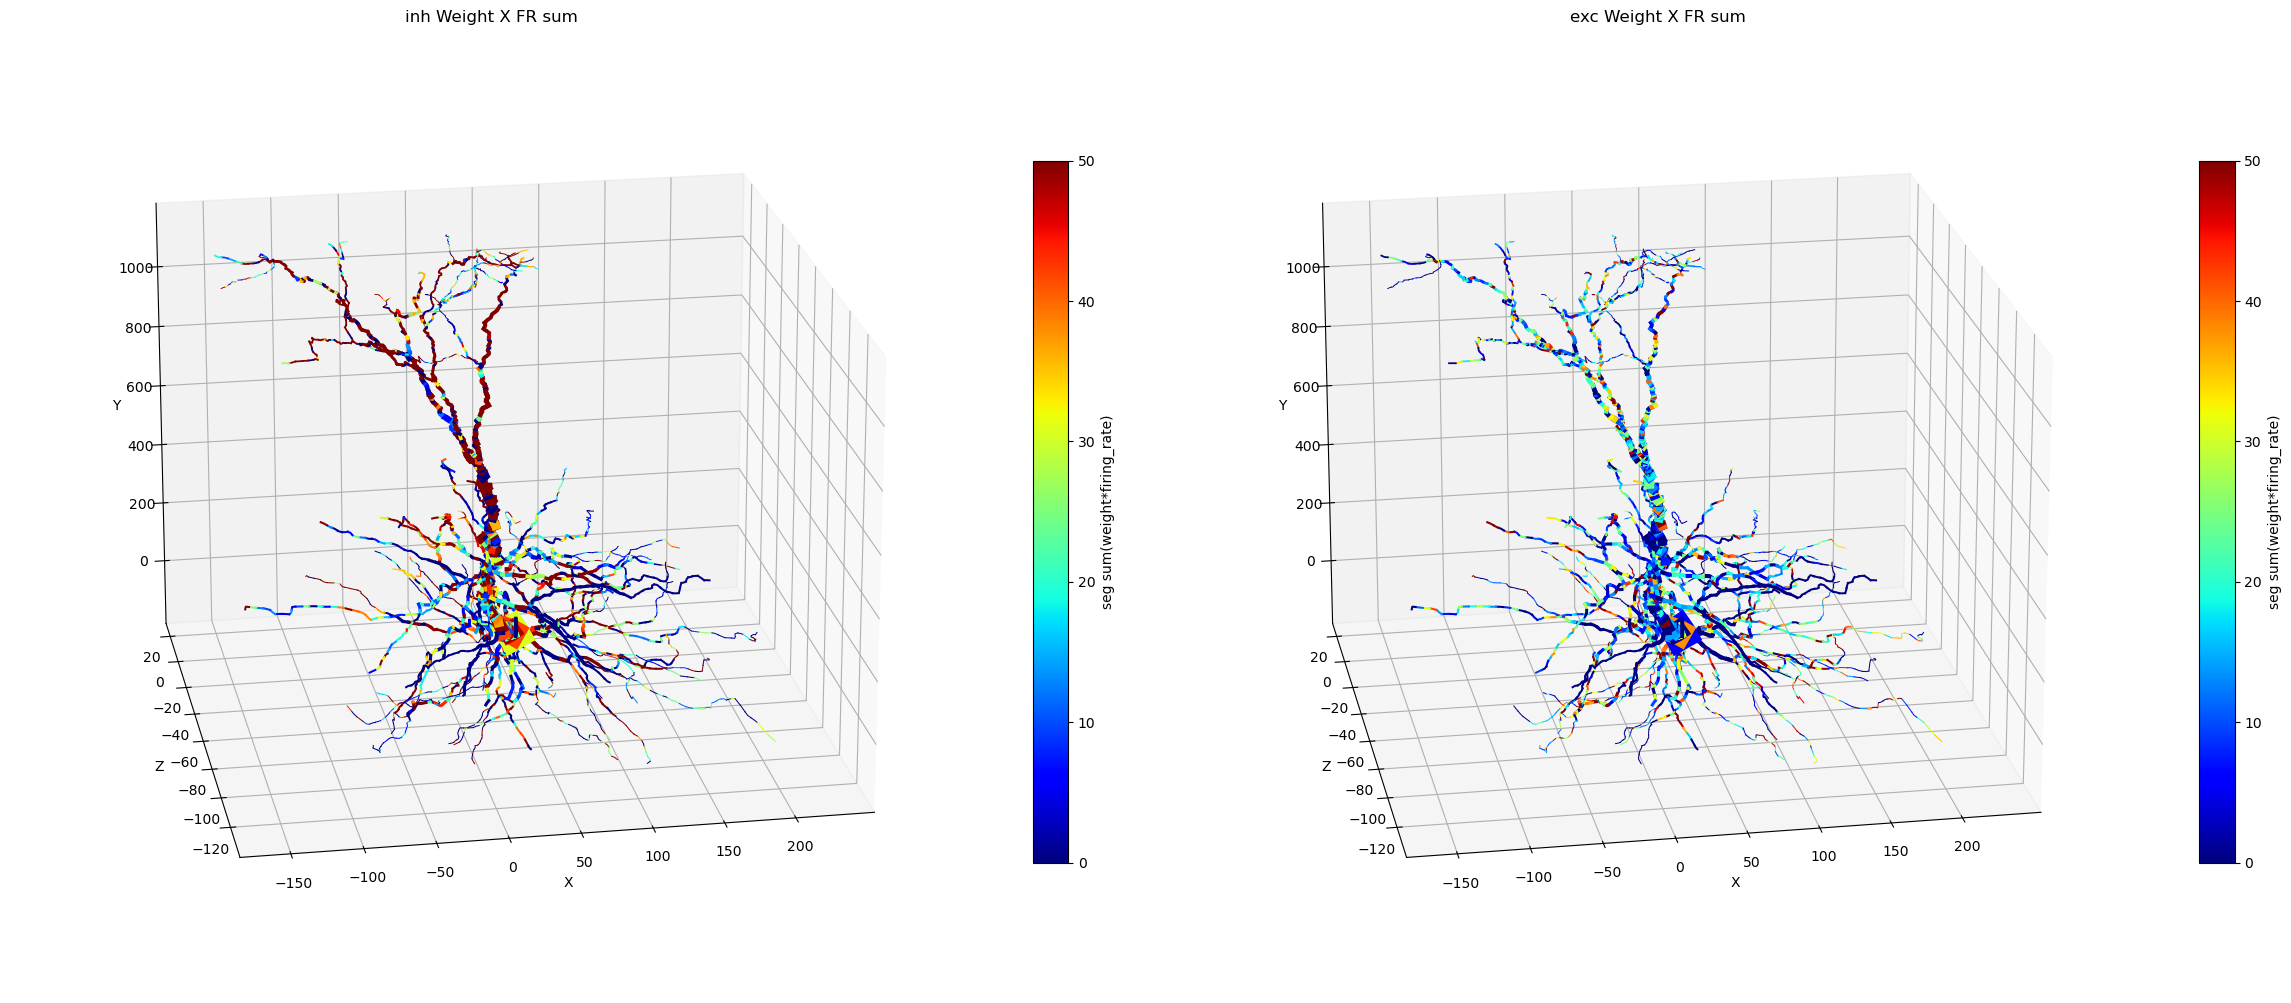

In [14]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='weightXfr_sum',
                                         cbar_label='seg sum(weight*firing_rate)',
                                         title_suffix='Weight X FR sum',
                                         save_folder=save_folder,
                                         clim_max = 50)

Firing Rate

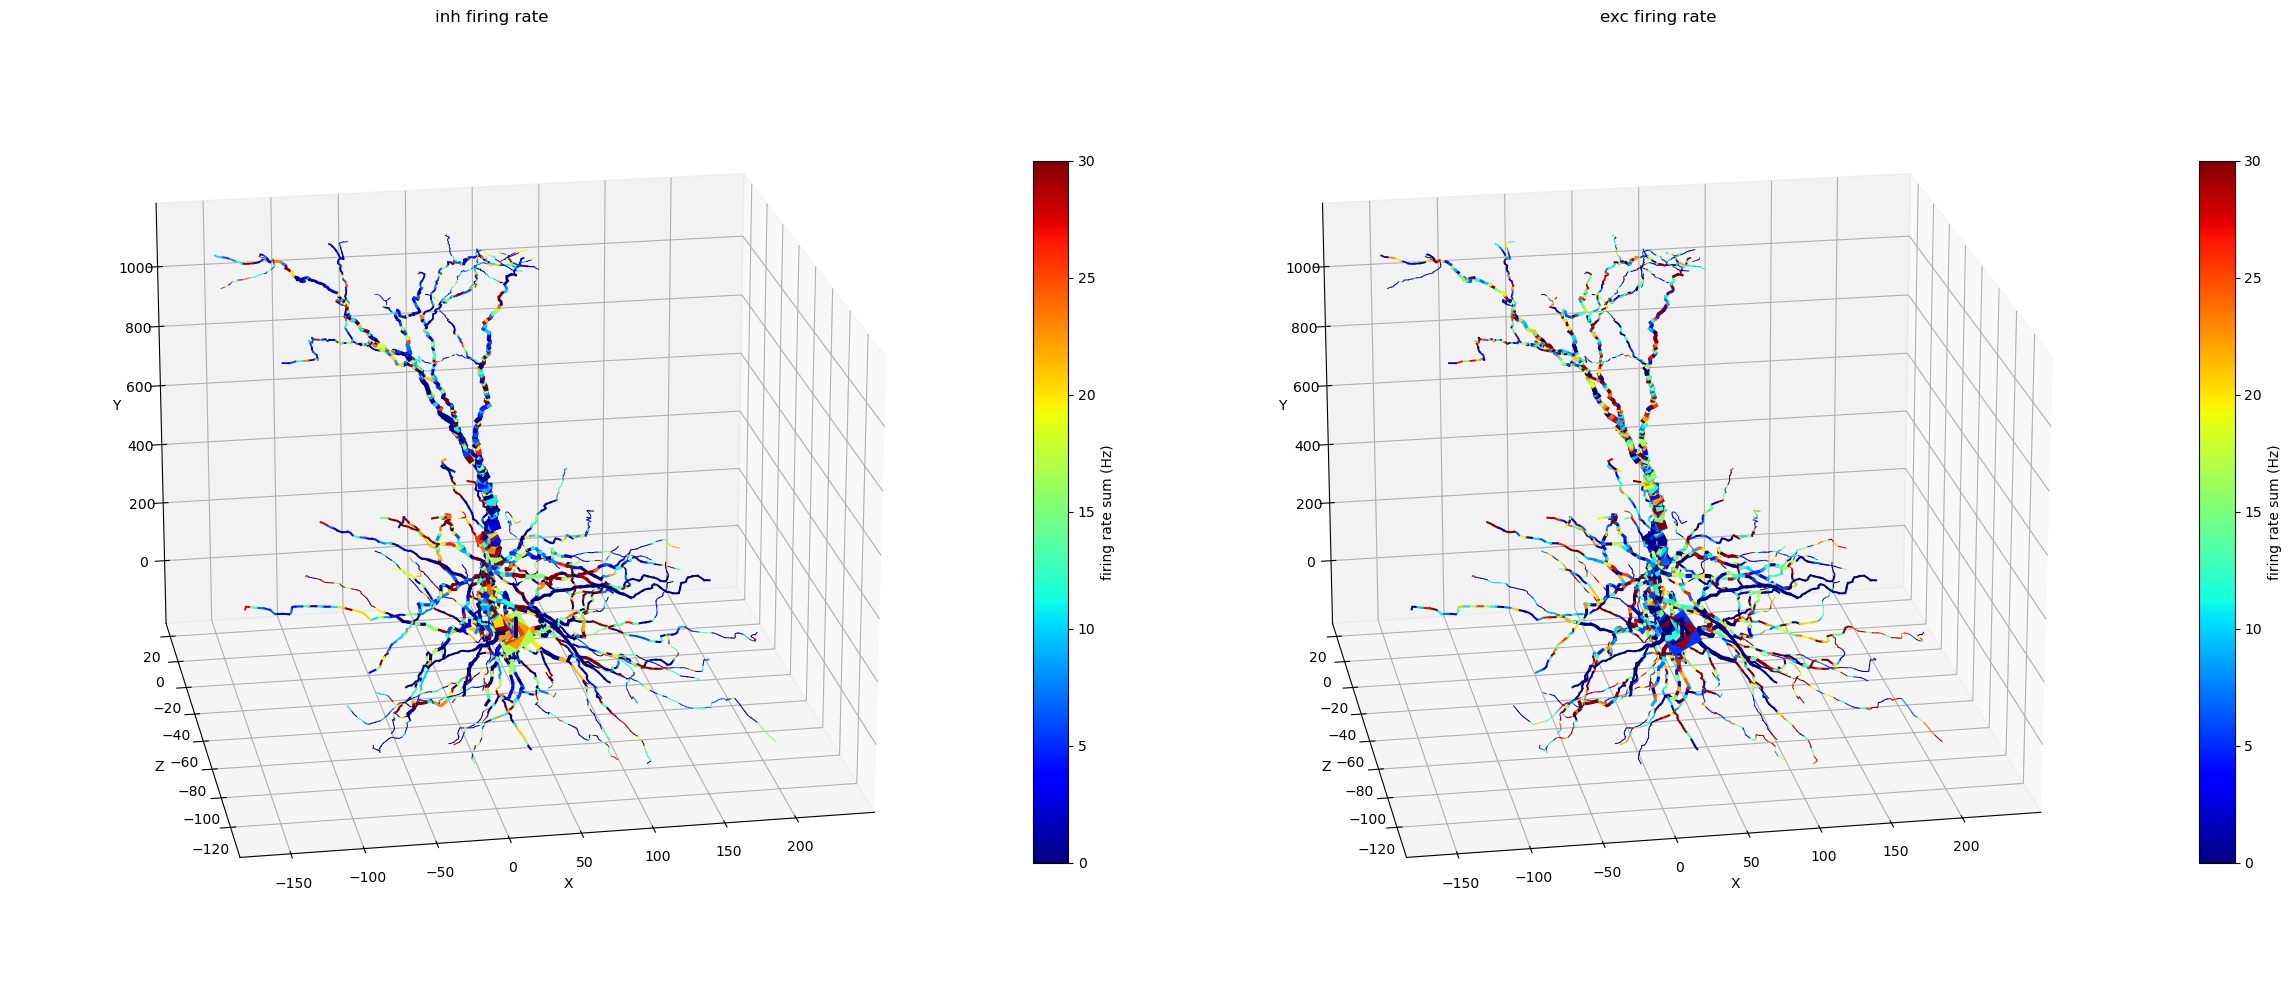

In [15]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='fr_sum',
                                         cbar_label='firing rate sum (Hz)',
                                         title_suffix='firing rate',
                                         save_folder=save_folder,
                                         clim_max = 30)

synapse density

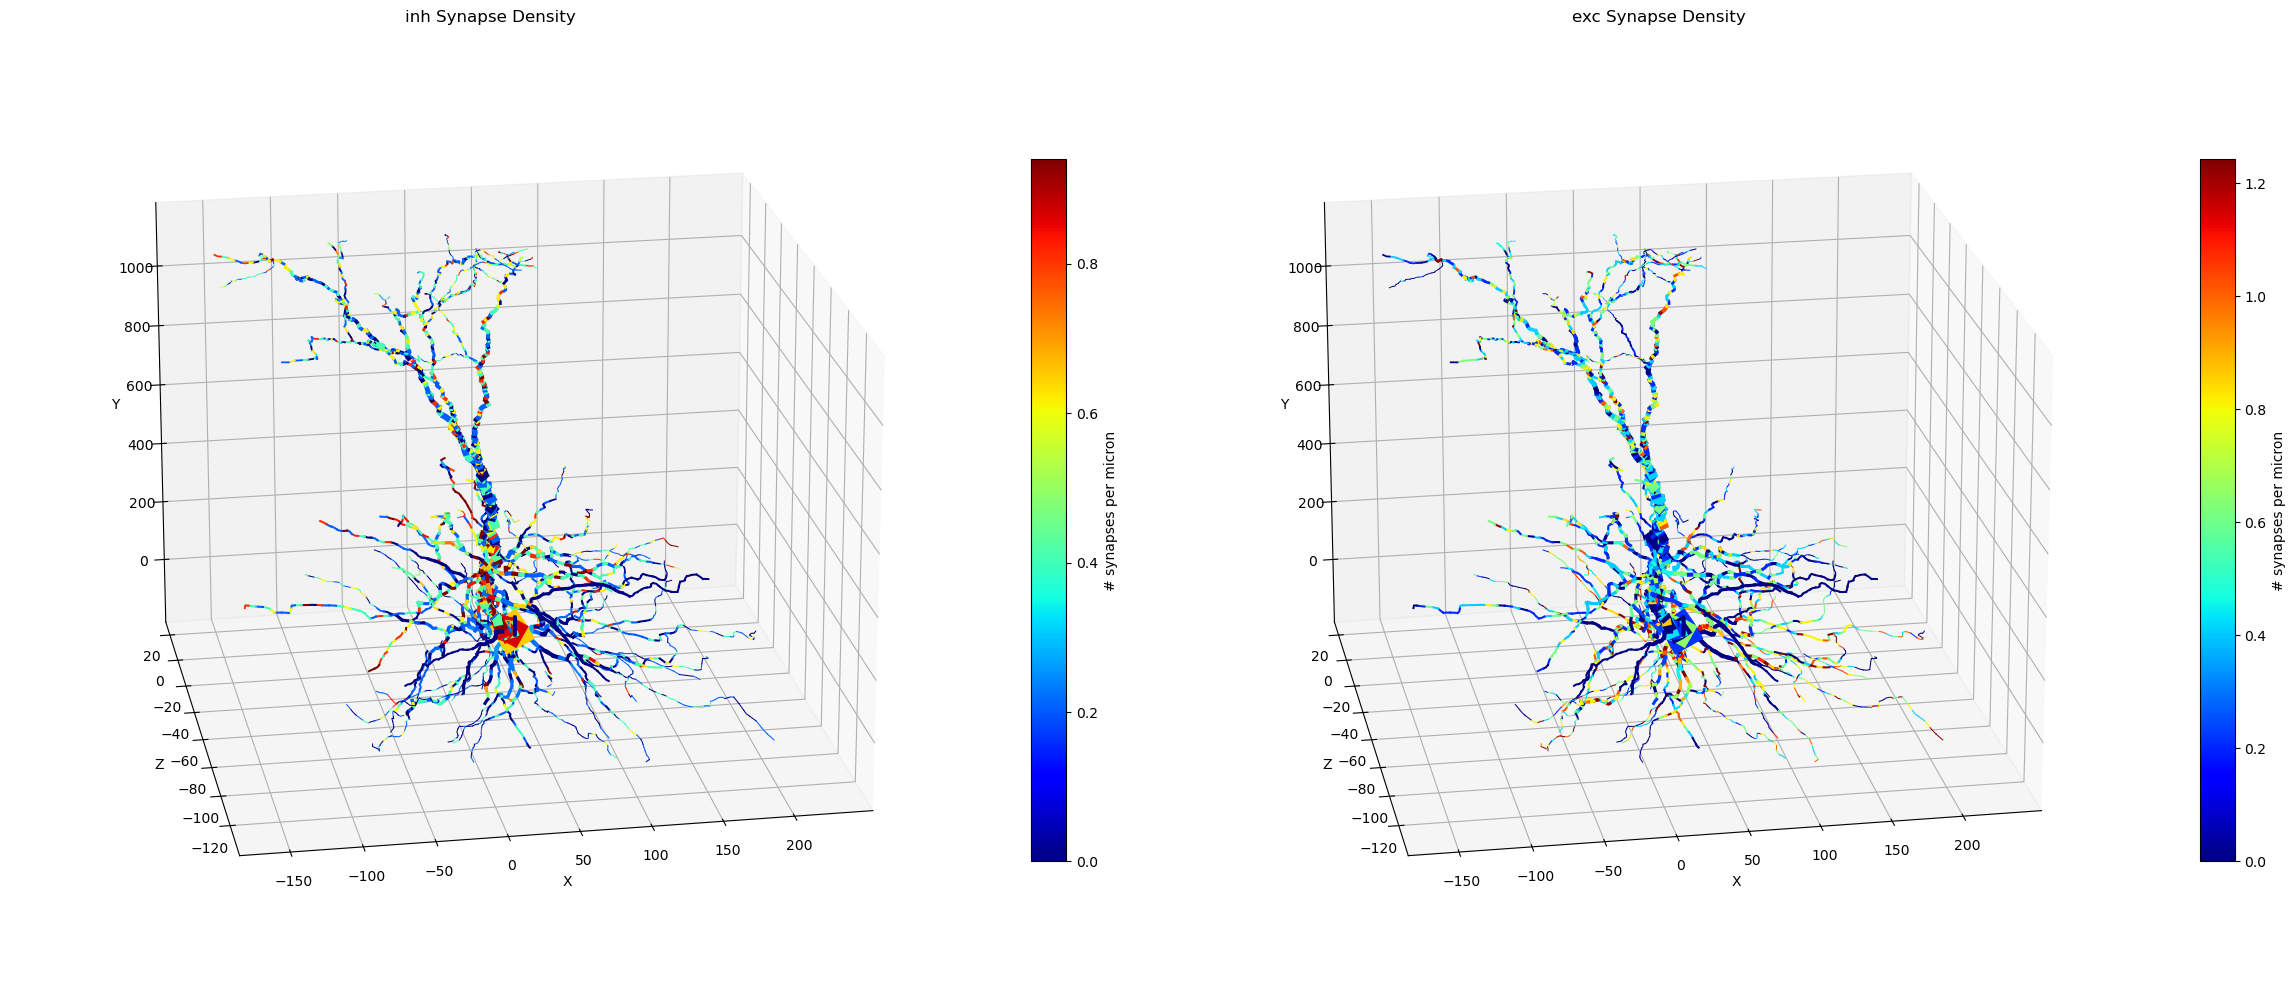

In [16]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='syn_density',
                                         cbar_label='# synapses per micron',
                                         title_suffix='Synapse Density',
                                         save_folder=save_folder,
                                         clim_max=None)

number of synapses

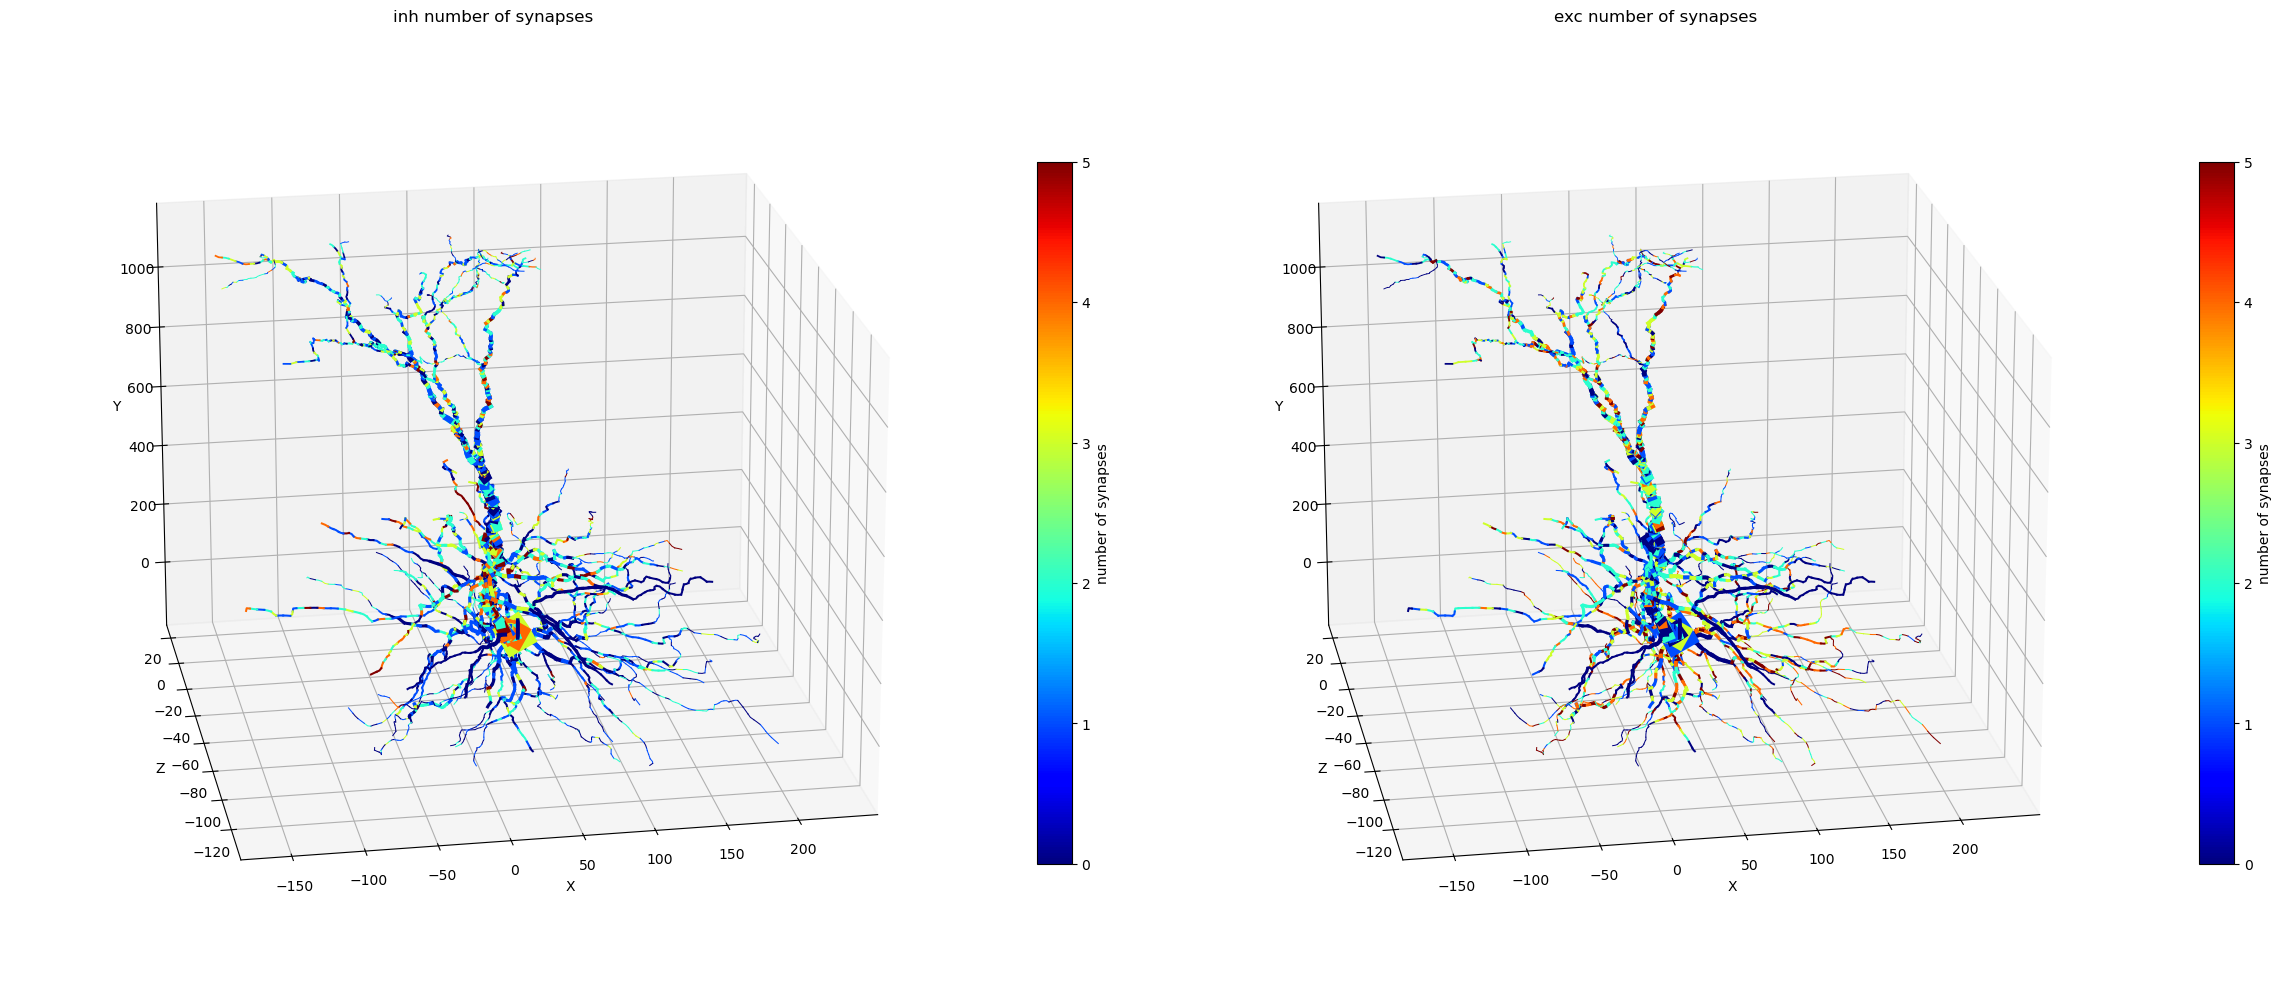

In [17]:
plot_var_on_morph_for_both_syn_types(df_inh=df_inh_grouped,
                                         df_exc=df_exc_grouped,
                                         var='num_syns',
                                         cbar_label='number of synapses',
                                         title_suffix='number of synapses',
                                         save_folder=save_folder,
                                         clim_max=5)